# NOVEL Sweep B1 Field
## Author: Vineeth Francis Thalakottoor, vineeth.thalakottoor@ens.psl.eu or vineethfrancis.physics@gmail.com
- Nuclear Orientation via Electron Spin Locking
- In Hilbert Space
- Redfield Master equation
- Thanks to Pulsed DNP Workshop at Lyon 2026 (Sami Jannin and team)

In [1]:
# Define the source path
SourcePath = '/media/HD2/Vineeth/PostDoc_Simulations/Github/PyOR_V1/PyOR_Combined/PyOR/Source_Doc'

# Add source path
import sys
sys.path.append(SourcePath)
import time
%matplotlib ipympl

# Import PyOR package
from PyOR_QuantumSystem import QuantumSystem as QunS
from PyOR_Hamiltonian import Hamiltonian
from PyOR_DensityMatrix import DensityMatrix
from PyOR_QuantumObject import QunObj
from PyOR_HardPulse import HardPulse
from PyOR_Basis import Basis
from PyOR_Evolution import Evolutions
from PyOR_Plotting import Plotting
import PyOR_SignalProcessing as Spro

import numpy as np

In [2]:
# Define the spin system
Spin_list = {"A" : "E", "B" : "H1"}
QS = QunS(Spin_list,PrintDefault=False)
QS.print_Larmor = False
# initialize the system
QS.Initialize()

### Set parameters

In [3]:
# Master Equation
QS.PropagationSpace = "Hilbert"
QS.MasterEquation = "Redfield"

# B0 Field in Tesla, Static Magnetic field (B0) along Z
QS.B0 = 0.3475

# Offset Frequency in rotating frame (Hz)
QS.OFFSET["A"] = 0.0
QS.OFFSET["B"] = 0.0

# Relaxation Process
QS.Rprocess = "No Relaxation"

QS.Update()


Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [61194749999.99999, -92963895.0] from {'A': 61194749999.99999, 'B': -92963895.0}
Offset    <- OFFSET    : [0.0, 0.0] from {'A': 0.0, 'B': 0.0}
Ispintemp <- I_spintemp: [300, 300] from {'A': 300, 'B': 300}
Fspintemp <- F_spintemp: [300, 300] from {'A': 300, 'B': 300}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------


# NOVEL

In [4]:
nPoints = 100
nB1Points = 200
IB1 = 0.5
FB1 = 1.5
Intensity = np.zeros((nB1Points))
OMEGA1 = np.linspace(IB1,FB1,nB1Points)
j = 0

start_time = time.time()
for i in OMEGA1:
    Omega_A = QS.OMEGA_RF["B"] # Proton Larmor Frequency
    Omega1 = i * Omega_A       # NOVEL condition, Match Rabi frequnecy to Nuclear Larmor
    A = 2.0 * 3.14 * 1.0e6     # Hyperfine coupling

    Hz = Omega_A * QS.Bz       # Nuclear Zeeman Hamiltonina  
    Hh = A * QS.Az * QS.Bx     # Hyperfine coupling
    Hm = Omega1 * QS.Ax        # Microwave
    H = Hz + Hh + Hm           # Total Hamiltonian

    rho_in = QS.Az             # Initial Density Matrix
    rhoeq = QS.Az

    # Pulse
    HardP = HardPulse(QS)
    flip_angle1 = 90.0   # Flip angle Spin 1
    rho = HardP.Rotate_Pulse(rho_in,flip_angle1,QS.Ay)

    # Evolution
    Contact_time = 2e-6
    QS.AcqDT =  Contact_time / nPoints
    QS.AcqAQ = Contact_time

    QS.PropagationMethod = "Unitary Propagator"

    Ham = Hamiltonian(QS)
    EVol = Evolutions(QS,Ham)

    t, rho_t = EVol.Evolution(rho,rhoeq,H)

    # Expectation
    det_X1 = QS.Ax
    det_Z2 = QS.Bz

    t, signal_X1 = EVol.Expectation(rho_t,det_X1)
    t, signal_Z2 = EVol.Expectation(rho_t,det_Z2)
    Intensity[j] = np.sum(signal_Z2.real)
    OMEGA1[j]    = Omega1/Omega_A
    j = j + 1
    end_time = time.time()
    timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Total time = 0.7749249935150146 seconds 


## Plotting

In [5]:
plot = Plotting(QS)

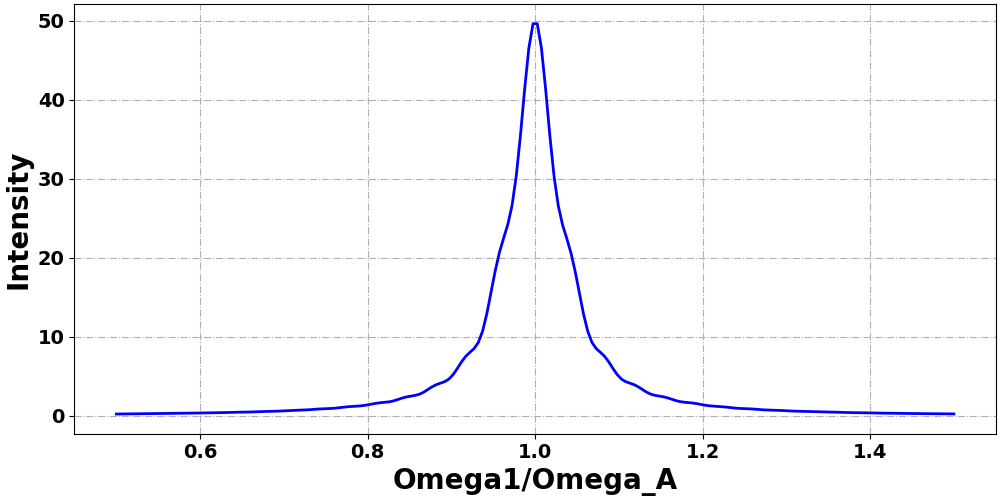

In [6]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 20
plot.Plotting(OMEGA1,Intensity,"Omega1/Omega_A","Intensity","blue")